# 🎵 Müzik Duygu Analizi - Örüntü Tanıma Projesi

Bu çalışmada kullanıcıların yazdığı mesajlardan duygu durumlarını (Happy, Sad, Relaxed, vs.) tahmin edecek bir makine öğrenmesi modeli geliştirilecektir.

Tüm işlemler bu notebook üzerinden adım adım yürütülecektir:
- Veri yükleme
- Temizlik ve ön işleme
- Görselleştirme
- Özellik mühendisliği
- Model eğitimi
- Performans değerlendirmesi


# 📘 Modül 1: Proje Tanıtımı ve Amaç

Bu projede, kullanıcıların yazdığı müzikle ilgili mesajlardan yola çıkarak onların ruh halini (duygusunu) tahmin eden bir makine öğrenmesi modeli geliştirilecektir.

Amaç:
- Duygu sınıflandırması yapmak (Happy, Sad, Relaxed vb.)
- NLP ön işleme tekniklerini uygulamak
- Görselleştirme ve örüntü çıkarımı yapmak
- Sıfırdan bir ML modeli eğitmek


# 📦 Modül 2: Gerekli Kütüphanelerin Yüklenmesi ve Veri Kümesinin Yüklenmesi


In [ ]:
#pip install pandas matplotlib seaborn numpy
#pip install notebook ipykernel

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dosya yolu
file_path = "data/music_sentiment_dataset.csv"

# Veri setini oku
df = pd.read_csv(file_path)

# İlk 5 satırı göster
df.head()


,User_ID,User_Text,Sentiment_Label,Recommended_Song_ID,Song_Name,Artist,Genre,Tempo (BPM),Mood,Energy,Danceability
0,U1,Way ball purpose public experience recently re...,Sad,S1,Someone Like You,Adele,Pop,67,Melancholic,Low,Low
1,U2,Save officer two myself a.,Happy,S2,Happy,Pharrell Williams,Pop,160,Joyful,High,High
2,U3,Decade ahead everyone environment themselves a...,Relaxed,S3,Clair de Lune,Debussy,Classical,60,Soothing,Low,Low
3,U4,Best change letter citizen try ask quality pro...,Happy,S4,Happy,Pharrell Williams,Pop,160,Joyful,High,High
4,U5,Worker player chance kind actually.,Happy,S5,Happy,Pharrell Williams,Pop,160,Joyful,High,High


# 🔍 Modül 3: Veri Kümesi Genel İncelemesi ve Eksik Değer Kontrolü


In [2]:
# Veri setinin genel yapısı
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   User_ID              1000 non-null   object
 1   User_Text            1000 non-null   object
 2   Sentiment_Label      1000 non-null   object
 3   Recommended_Song_ID  1000 non-null   object
 4   Song_Name            1000 non-null   object
 5   Artist               1000 non-null   object
 6   Genre                1000 non-null   object
 7   Tempo (BPM)          1000 non-null   int64 
 8   Mood                 1000 non-null   object
 9   Energy               1000 non-null   object
 10  Danceability         1000 non-null   object
dtypes: int64(1), object(10)
memory usage: 86.1+ KB


In [3]:
df.describe()

,Tempo (BPM)
count,1000.00000
mean,97.76000
std,36.74701
min,50.00000
25%,67.00000
50%,109.00000
75%,130.00000
max,160.00000


In [2]:
df = df.drop(columns=['User_ID','Recommended_Song_ID'])
df.head()

,User_Text,Sentiment_Label,Song_Name,Artist,Genre,Tempo (BPM),Mood,Energy,Danceability
0,Way ball purpose public experience recently re...,Sad,Someone Like You,Adele,Pop,67,Melancholic,Low,Low
1,Save officer two myself a.,Happy,Happy,Pharrell Williams,Pop,160,Joyful,High,High
2,Decade ahead everyone environment themselves a...,Relaxed,Clair de Lune,Debussy,Classical,60,Soothing,Low,Low
3,Best change letter citizen try ask quality pro...,Happy,Happy,Pharrell Williams,Pop,160,Joyful,High,High
4,Worker player chance kind actually.,Happy,Happy,Pharrell Williams,Pop,160,Joyful,High,High


In [5]:
# Eksik değerlerin dağılımı
df.isnull().sum()

User_Text          0
Sentiment_Label    0
Song_Name          0
Artist             0
Genre              0
Tempo (BPM)        0
Mood               0
Energy             0
Danceability       0
dtype: int64

In [6]:
df.columns

Index(['User_Text', 'Sentiment_Label', 'Song_Name', 'Artist', 'Genre',
       'Tempo (BPM)', 'Mood', 'Energy', 'Danceability'],
      dtype='object')

In [7]:
df['Sentiment_Label'].value_counts()

Sentiment_Label
Motivated    262
Happy        256
Sad          243
Relaxed      239
Name: count, dtype: int64

# 📊 Modül 4: Duygu Etiketlerinin Dağılımı


In [8]:
# Etiket sayıları
df['Sentiment_Label'].value_counts()

Sentiment_Label
Motivated    262
Happy        256
Sad          243
Relaxed      239
Name: count, dtype: int64

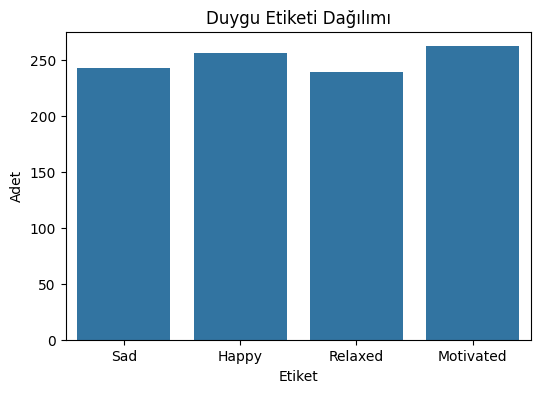

In [9]:
# Etiket dağılımı grafiği
plt.figure(figsize=(6, 4))
sns.countplot(x='Sentiment_Label', data=df)
plt.title("Duygu Etiketi Dağılımı")
plt.xlabel("Etiket")
plt.ylabel("Adet")
plt.show()


C:\Users\Monster\AppData\Local\Temp\ipykernel_21028\617966447.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= 'Song_Name', palette='viridis')


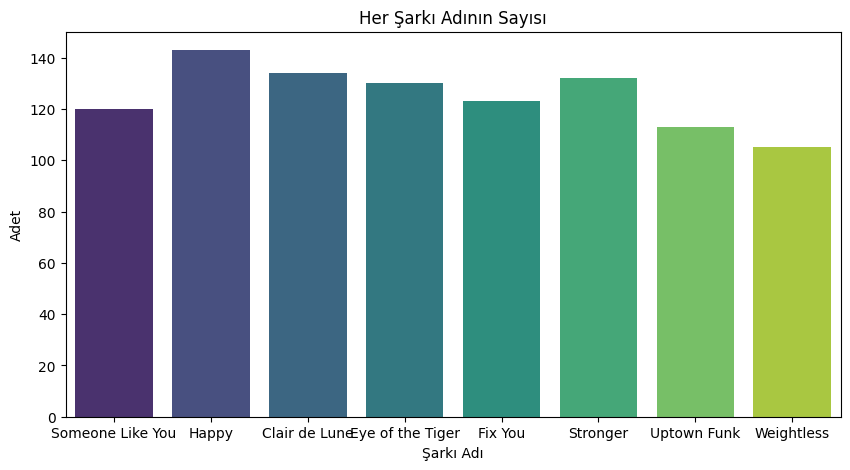

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x= 'Song_Name', palette='viridis')
plt.title("Her Şarkı Adının Sayısı")
plt.xlabel("Şarkı Adı")
plt.ylabel("Adet")
plt.show()

C:\Users\Monster\AppData\Local\Temp\ipykernel_21028\2770527072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= 'Artist', palette='viridis')


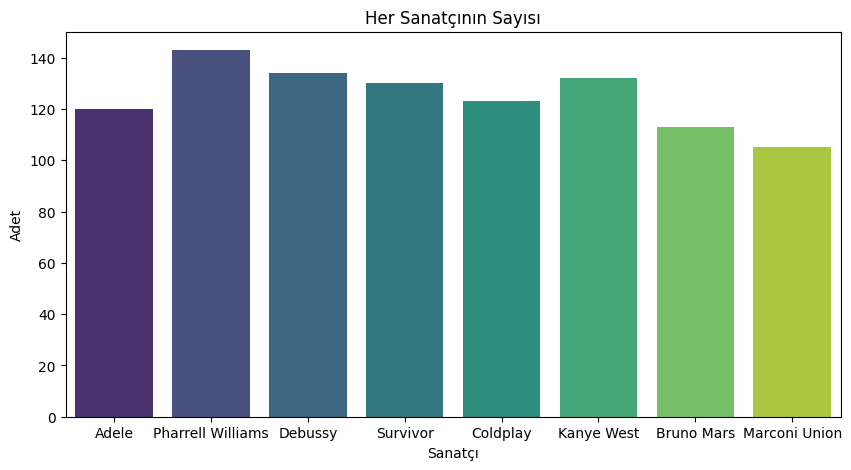

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x= 'Artist', palette='viridis')
plt.title("Her Sanatçının Sayısı")
plt.xlabel("Sanatçı")
plt.ylabel("Adet")
plt.show()

C:\Users\Monster\AppData\Local\Temp\ipykernel_21028\3588425358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= 'Genre', palette='viridis')


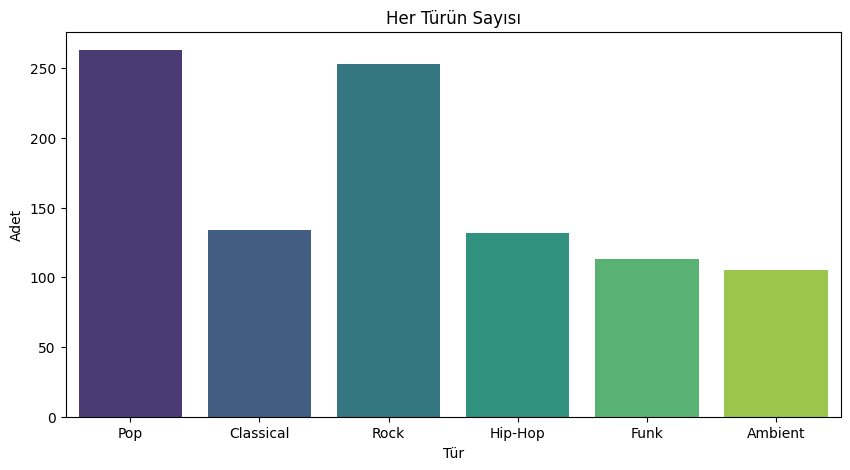

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x= 'Genre', palette='viridis')
plt.title("Her Türün Sayısı")
plt.xlabel("Tür")
plt.ylabel("Adet")
plt.show()

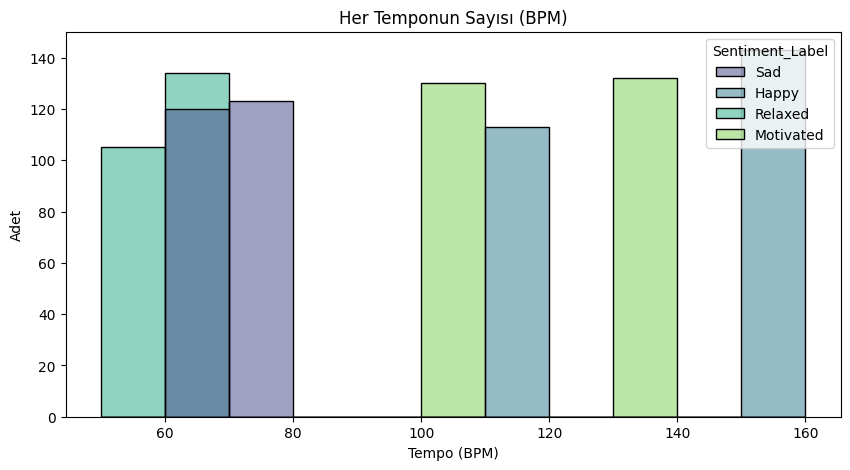

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(data = df, x= 'Tempo (BPM)',hue='Sentiment_Label', palette='viridis')
plt.title("Her Temponun Sayısı (BPM)")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Adet")
plt.show()

C:\Users\Monster\AppData\Local\Temp\ipykernel_21028\3879118099.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= 'Mood', palette='viridis')


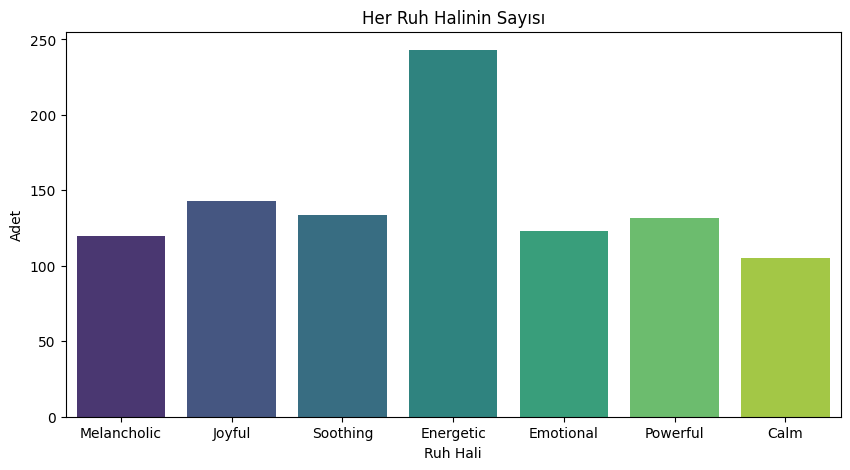

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x= 'Mood', palette='viridis')
plt.title("Her Ruh Halinin Sayısı")
plt.xlabel("Ruh Hali")
plt.ylabel("Adet")
plt.show()

C:\Users\Monster\AppData\Local\Temp\ipykernel_21028\234983349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x= 'Energy', palette='viridis')


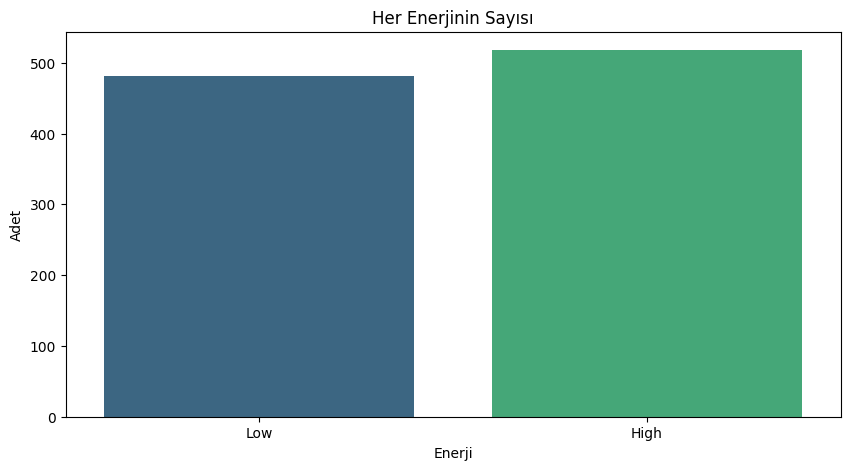

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x= 'Energy', palette='viridis')
plt.title("Her Enerjinin Sayısı")
plt.xlabel("Enerji")
plt.ylabel("Adet")
plt.show()

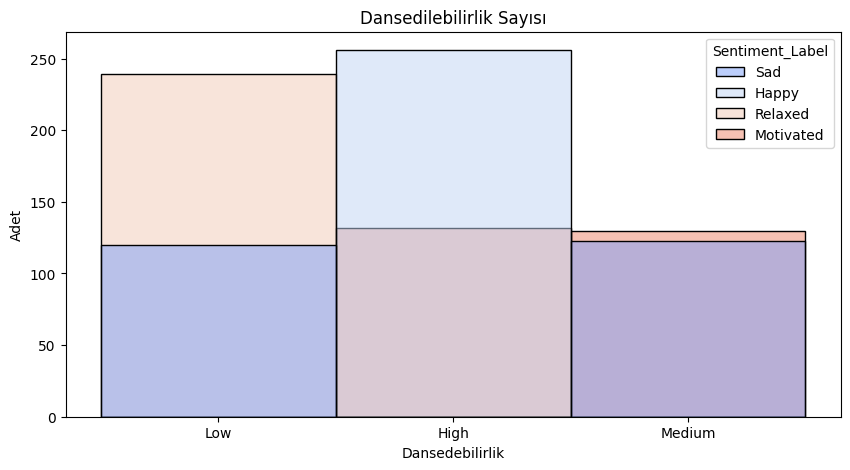

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(data = df, 
              x= 'Danceability',
              hue='Sentiment_Label',               
              palette='coolwarm')
plt.title("Dansedilebilirlik Sayısı")
plt.xlabel("Dansedebilirlik")
plt.ylabel("Adet")
plt.show()

# 🧹 Modül 5: Metin Temizliği

Bu modülde, kullanıcıların yazdığı metinler üzerinde temel temizlik, normalizasyon işlemleri yapılacaktır:

- Küçük harfe çevirme
- Noktalama işaretlerini kaldırma
- Sayıları ve özel karakterleri temizleme
- Gereksiz boşlukları sadeleştirme


In [2]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Önişleme uygulanmış sütun ekle
df['Clean_Text'] = df['User_Text'].apply(clean_text)

# Örnek kontrol
df[['User_Text', 'Clean_Text']].head()


,User_Text,Clean_Text
0,Way ball purpose public experience recently re...,way ball purpose public experience recently re...
1,Save officer two myself a.,save officer two myself a
2,Decade ahead everyone environment themselves a...,decade ahead everyone environment themselves a...
3,Best change letter citizen try ask quality pro...,best change letter citizen try ask quality pro...
4,Worker player chance kind actually.,worker player chance kind actually


# 🧠 Modül 6: Tokenization ve Stopword Temizliği (İngilizce)

Bu modülde:
- Metinler İngilizce olarak kelimelere ayrılacak (tokenization)
- Anlam taşımayan **İngilizce stopword**'ler kaldırılacak

> Örnek stopword'ler: *the, is, and, I, in, on...*


In [ ]:
#pip install spacy
#python -m spacy download en_core_web_sm


In [21]:
import spacy

nlp = spacy.load("en_core_web_sm")

def tokenize_with_spacy(text):
    doc = nlp(text)
    return " ".join([token.text for token in doc if token.is_alpha and not token.is_stop])

df["Processed_Text"] = df["Clean_Text"].apply(tokenize_with_spacy)



In [22]:
df[['Clean_Text', 'Processed_Text']].head()

,Clean_Text,Processed_Text
0,way ball purpose public experience recently re...,way ball purpose public experience recently re...
1,save officer two myself a,save officer
2,decade ahead everyone environment themselves a...,decade ahead environment action health
3,best change letter citizen try ask quality pro...,best change letter citizen try ask quality pro...
4,worker player chance kind actually,worker player chance kind actually


In [3]:
custom_excluded = {
    "a", "about", "above", "after", "again", "against", "ain", "all", "am", "an", "and", "any", "are", 
    "aren", "aren't", "as", "at", "be", "because", "been", "before", "being", "below", "between", 
    "both", "but", "by", "can", "couldn", "couldn't", "d", "did", "didn", "didn't", "do", "does", 
    "doesn", "doesn't", "doing", "don", "don't", "down", "during", "each", "few", "for", "from", 
    "further", "had", "hadn", "hadn't", "has", "hasn", "hasn't", "have", "haven", "haven't", "having", 
    "he", "he'd", "he'll", "her", "here", "hers", "herself", "he's", "him", "himself", "his", "how", 
    "i", "i'd", "if", "i'll", "i'm", "in", "into", "is", "isn", "isn't", "it", "it'd", "it'll", "it's", 
    "its", "itself", "i've", "just", "ll", "m", "ma", "me", "mightn", "mightn't", "more", "most", 
    "mustn", "mustn't", "my", "myself", "needn", "needn't", "no", "nor", "not", "now", "o", "of", 
    "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out", "over", "own", "re", 
    "s", "same", "shan", "shan't", "she", "she'd", "she'll", "she's", "should", "shouldn", 
    "shouldn't", "should've", "so", "some", "such", "t", "than", "that", "that'll", "the", "their", 
    "theirs", "them", "themselves", "then", "there", "these", "they", "they'd", "they'll", "they're", 
    "they've", "this", "those", "through", "to", "too", "under", "until", "up", "ve", "very", "was", 
    "wasn", "wasn't", "we", "we'd", "we'll", "we're", "were", "weren", "weren't", "we've", "what", 
    "when", "where", "which", "while", "who", "whom", "why", "will", "with", "won", "won't", "wouldn", 
    "wouldn't", "y", "you", "you'd", "you'll", "your", "you're", "yours", "yourself", "yourselves", 
    "you've"
}


In [4]:
import spacy

nlp = spacy.load("en_core_web_sm")

def custom_tokenize(text):
    doc = nlp(text)
    return " ".join([
        token.lemma_ for token in doc
        if token.is_alpha and len(token.text) > 2 and token.text.lower() not in custom_excluded
    ])

df["Processed_Text"] = df["Clean_Text"].apply(custom_tokenize)


In [5]:
df[['Clean_Text', 'Processed_Text']].head()

,Clean_Text,Processed_Text
0,way ball purpose public experience recently re...,way ball purpose public experience recently re...
1,save officer two myself a,save officer two
2,decade ahead everyone environment themselves a...,decade ahead everyone environment action health
3,best change letter citizen try ask quality pro...,good change letter citizen try ask quality pro...
4,worker player chance kind actually,worker player chance kind actually


# 🎨 Modül 7 – WordCloud & Duygu Bazlı Kelime Görselleştirme

Bu modülde, önceden temizlenmiş `Processed_Text` kolonumuz üzerinden metinlerin kelime bulutunu (WordCloud) oluşturacağız.WordCloud (Kelime Bulutu), bir metin kümesindeki en sık geçen kelimeleri görsel olarak öne çıkaran bir görselleştirme tekniğidir.
Kelimenin görseldeki boyutu, o kelimenin verideki tekrar sıklığını temsil eder.Örüntüleri tanımamıza yardımcı olur.

## 🔹 Amaçlar:

- Temizlenmiş verilerden **anlamlı kelime örüntülerini** görsel olarak sunmak  
- Verinin genel yapısını sezgisel olarak analiz etmek  
- **Duygu etiketlerine göre** ayrı WordCloud'lar oluşturmak  
  - Örnek: `happy`, `sad`, `angry` gibi duygular için farklı bulutlar

## 🛠 Kullanılacak Teknolojiler:

- `wordcloud`: Kelime bulutu oluşturmak için
- `matplotlib`: Görselleştirme için

## 📦 Hazırlık:

- `WordCloud` kütüphanesini yüklemeniz gerekicek:  
  ```python
  pip install wordcloud matplotlib --quiet


c:\Users\Monster\Desktop\music-mood-app\nlp-model\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128292 (\N{INPUT SYMBOL FOR LATIN LETTERS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


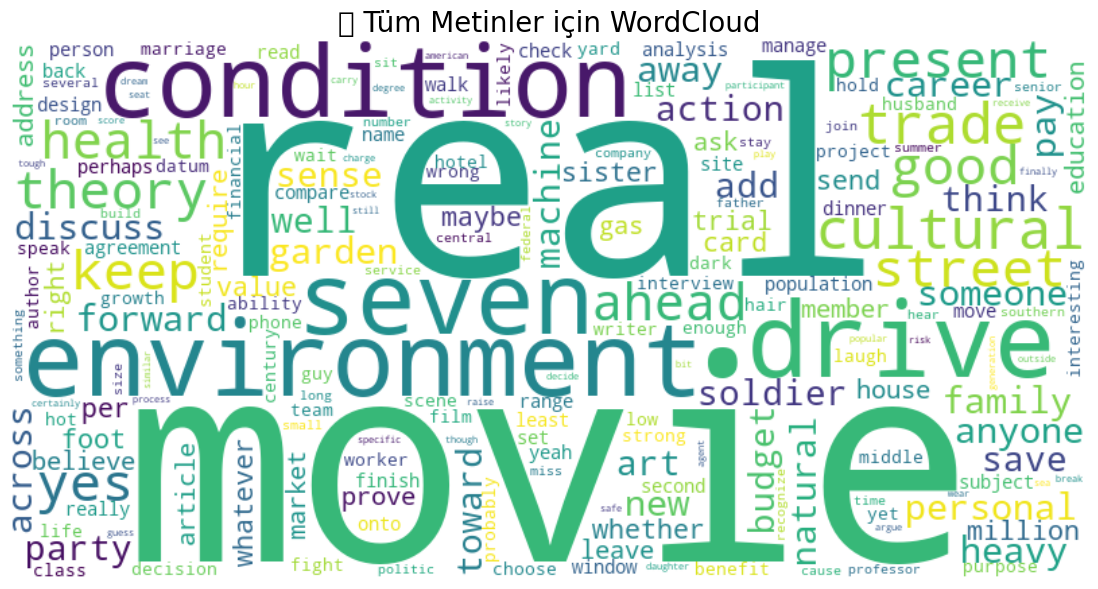

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Tüm temizlenmiş metni birleştir
all_text = " ".join(df["Processed_Text"])

# WordCloud oluştur
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_text)

# Görselleştir
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("🔤 Tüm Metinler için WordCloud", fontsize=20)
plt.show()


In [27]:
df["Mood"].value_counts()

Mood
Energetic      243
Joyful         143
Soothing       134
Powerful       132
Emotional      123
Melancholic    120
Calm           105
Name: count, dtype: int64

c:\Users\Monster\Desktop\music-mood-app\nlp-model\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127911 (\N{HEADPHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


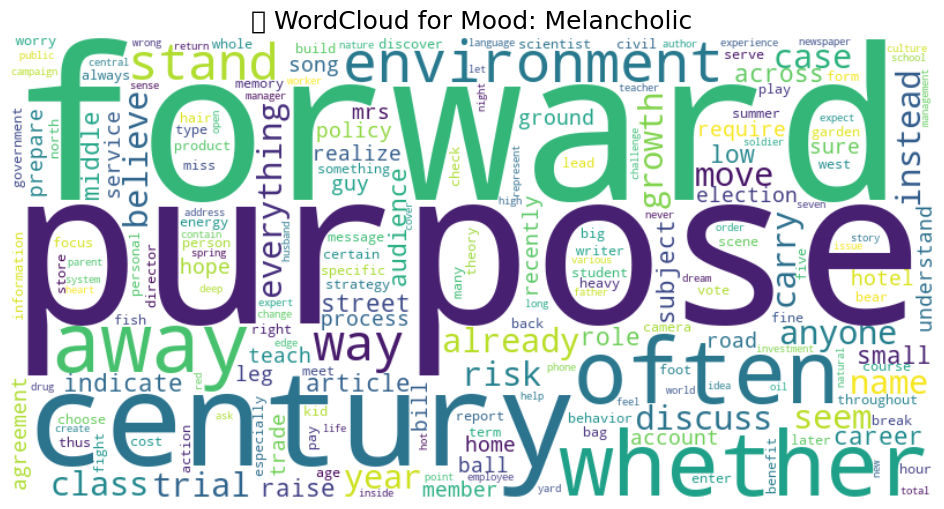

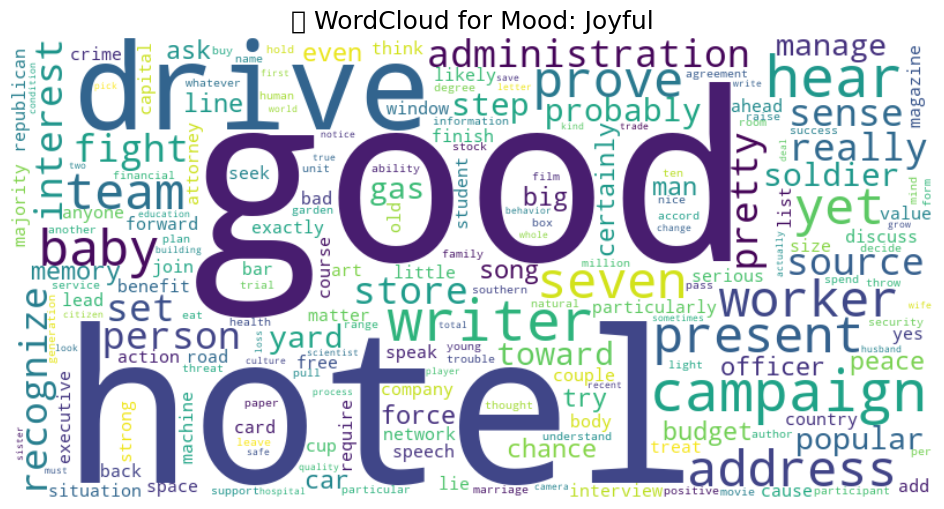

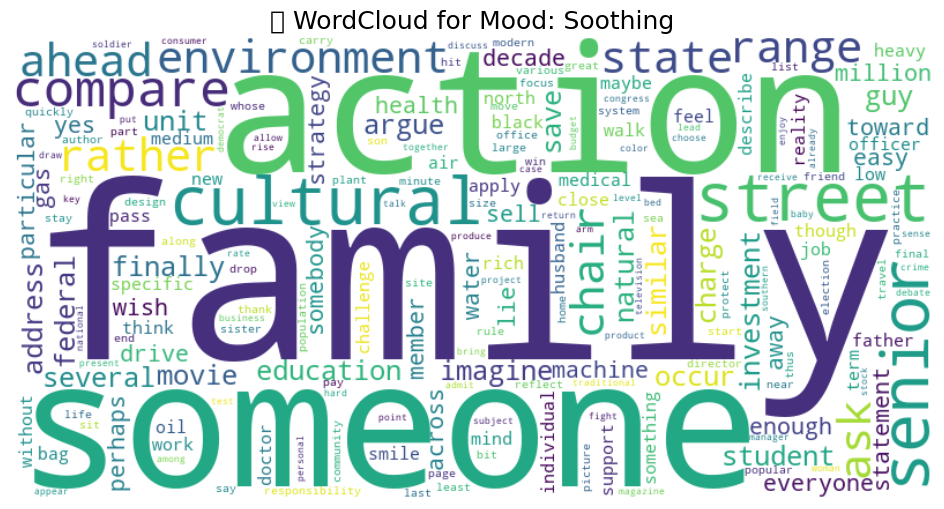

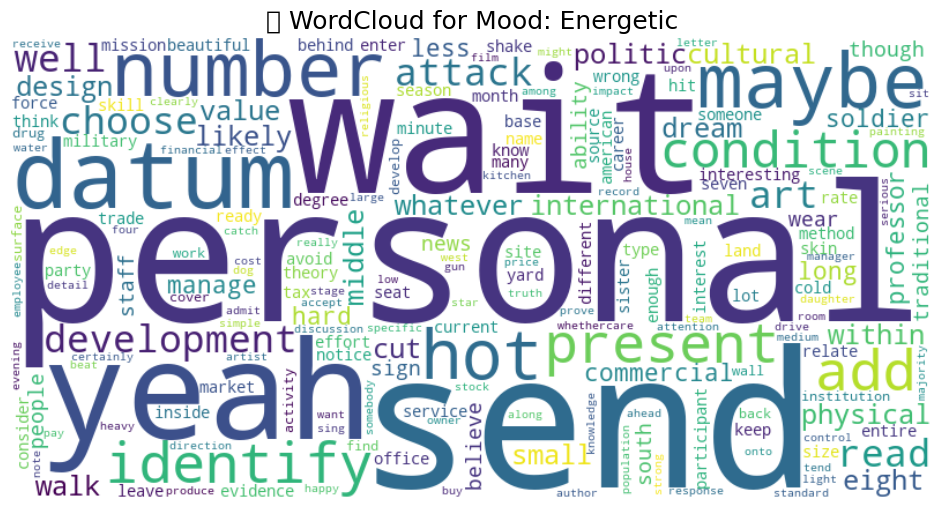

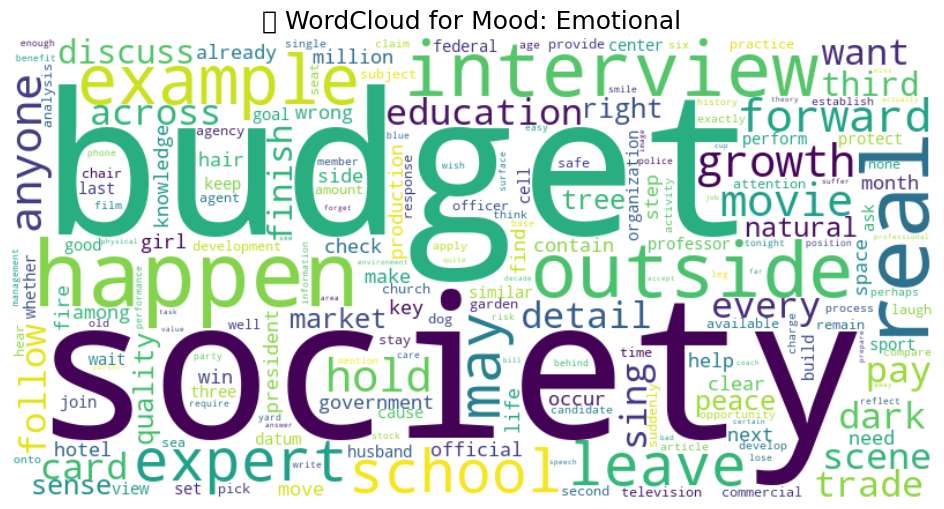

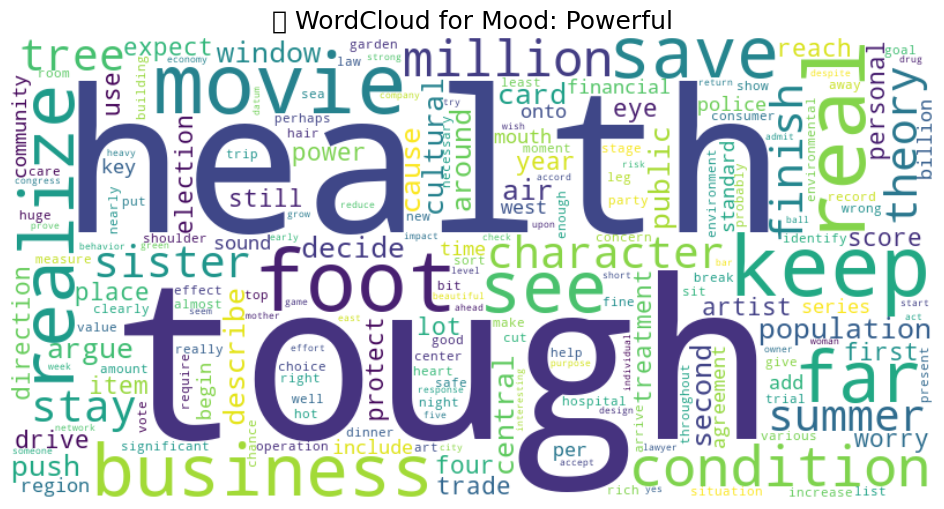

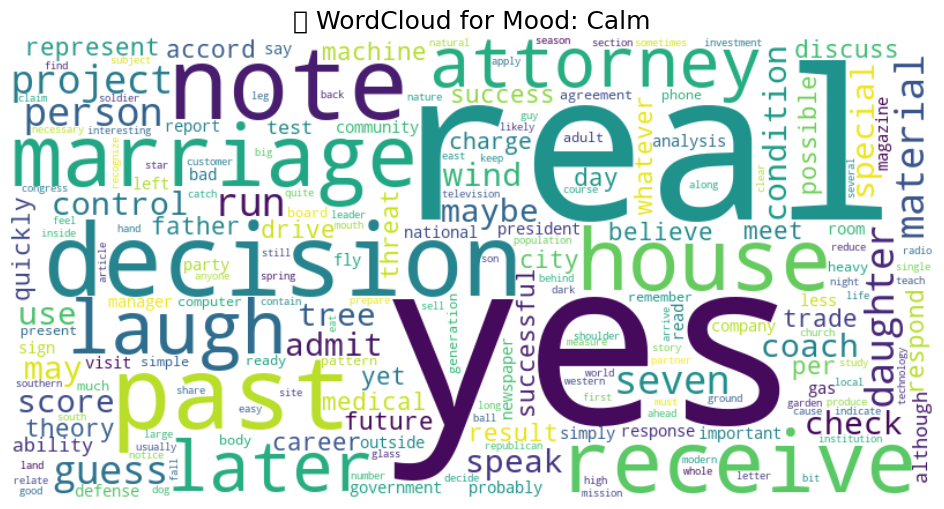

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Mood'lara göre gruplama ve görselleştirme
unique_moods = df["Mood"].dropna().unique()

# Her bir Mood için ayrı WordCloud
for mood in unique_moods:
    mood_text = " ".join(df[df["Mood"] == mood]["Processed_Text"].dropna())

    # Eğer metin boşsa, o mood'u atla
    if len(mood_text.strip()) == 0:
        continue

    # WordCloud oluştur
    wc = WordCloud(width=800, height=400, background_color="white").generate(mood_text)

    # Görselleştir
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"🎧 WordCloud for Mood: {mood}", fontsize=18)
    plt.show()


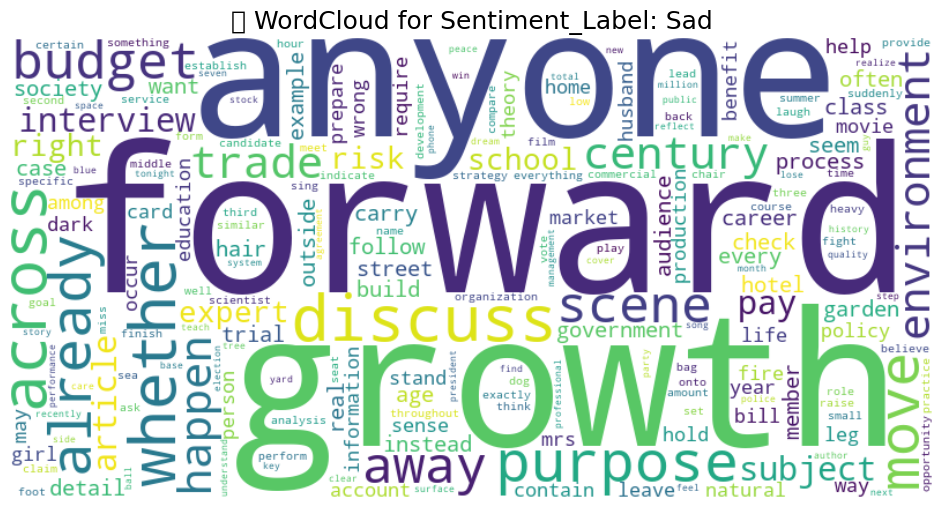

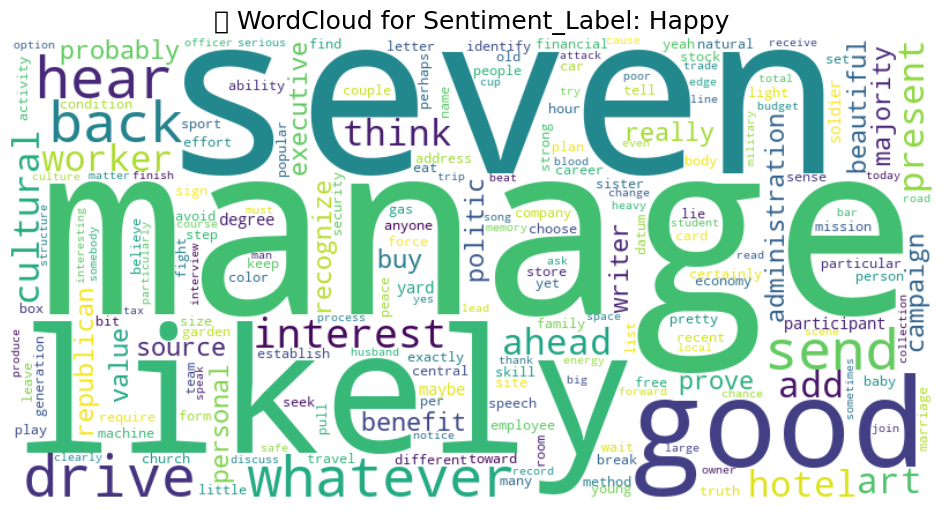

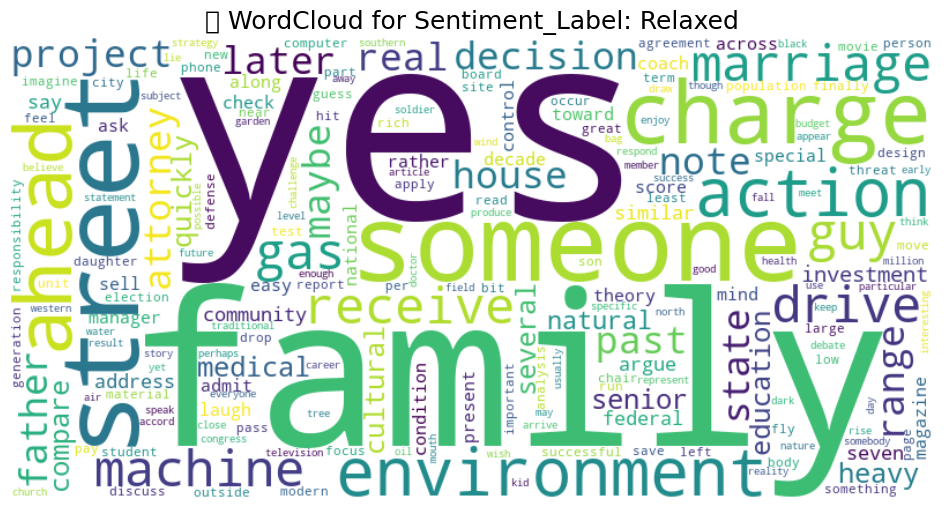

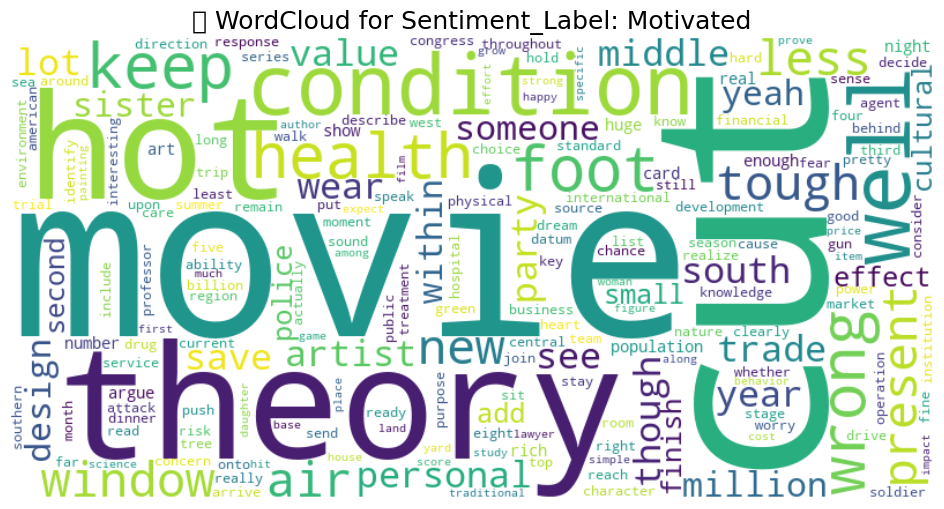

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Sentiment_Label'lara göre gruplama ve görselleştirme
unique_moods = df["Sentiment_Label"].dropna().unique()

# Her bir Sentiment_Label için ayrı WordCloud
for mood in unique_moods:
    mood_text = " ".join(df[df["Sentiment_Label"] == mood]["Processed_Text"].dropna())

    # Eğer metin boşsa, o mood'u atla
    if len(mood_text.strip()) == 0:
        continue

    # WordCloud oluştur
    wc = WordCloud(width=800, height=400, background_color="white").generate(mood_text)

    # Görselleştir
    plt.figure(figsize=(14, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"🎧 WordCloud for Sentiment_Label: {mood}", fontsize=18)
    plt.show()


# 📊 Modül 8 – TF-IDF ve Transformer Tabanlı Modelleme

Bu modülde hem **TF-IDF** hem de **BERT (Transformer) tabanlı embedding** kullanarak metinler üzerinde duygu tahmini yapacağız.  

## 🎯 Amaçlar

- Kelimeleri vektörleştirip makine öğrenmesi modeline dönüştürmek  
- Yüksek doğruluklu duygu tahmini (TF-IDF & BERT karşılaştırması)  
- TF-IDF ile "hangi kelime ne kadar önemli?" sorusuna cevap bulmak  
- BERT ile daha bağlamsal ve güçlü bir model üretmek  

---

## 🔹 1. TF-IDF: Açıklanabilirlik İçin

- Sadece kelime frekansına ve nadirliğine dayanır
- Çok hızlıdır ve kolay eğitilir
- Özellikle Logistic Regression ile birlikte **özellik önemleri** rahatça incelenebilir  
- Örnek: "Energetic" sınıfında `energy`, `vibe`, `feel` gibi kelimelerin etkisi

---

## 🔹 2. BERT (Transformer): Yüksek Doğruluk İçin

- Kelimeleri cümle bağlamında yorumlar
- `HuggingFace Transformers` kütüphanesi ile çalışır
- Pre-trained modeller kullanılarak fine-tune edilebilir
- Daha fazla işlem gücü gerektirir, ama doğruluk seviyesi çok yüksektir

---

## 🤝 Neden İkisini Birden Kullanıyoruz?

| TF-IDF                        | BERT                            |
|------------------------------|---------------------------------|
| Açıklanabilir ✔️             | Doğruluk yüksek ✔️             |
| Hızlı çalışır ✔️             | Bağlamsal analiz ✔️             |
| Özellik önemleri çıkar ✔️     | Derin anlam çıkarır ✔️          |
| Sunumda yorumlanabilir ✔️    | Üretim sistemlerinde güçlü ✔️  |

---

## 🔚 Sonuç

- BERT ile tahmin yapacağız ✅  
- TF-IDF ile analiz edeceğiz ✅  
- Bu sayede hem yüksek doğruluk hem de yüksek yorumlanabilirlik sağlayacağız 🔥


In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
import numpy as np
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# data pre-processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack
from scipy.sparse import csr_matrix
import scipy.sparse as sp

# machine learning model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

In [8]:
y = df['Sentiment_Label']
tfidf = TfidfVectorizer()
User_Text_tfidf = tfidf.fit_transform(df['Processed_Text'])
dense_matrix = User_Text_tfidf.toarray()
dense_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 859))

In [35]:
cols_to_encode = ['Song_Name','Artist','Genre','Mood','Energy','Danceability']
encoded_features = []
le_dict = {}
for col in cols_to_encode:
    le = LabelEncoder()
    encoded = le.fit_transform(df[col])
    encoded_features.append(encoded.reshape(-1,1))
    le_dict[col] = le
# Combine all encoded columns horizontally
X_encoded = np.hstack(encoded_features)
tempo = df[['Tempo (BPM)']].values
X_other = np.hstack([X_encoded,tempo])
X_other_sparse = sp.csr_matrix(X_other)
X_combined = hstack([User_Text_tfidf, X_other_sparse])
X_combined.toarray()

array([[  0.,   0.,   0., ...,   1.,   1.,  67.],
       [  0.,   0.,   0., ...,   0.,   0., 160.],
       [  0.,   0.,   0., ...,   1.,   1.,  60.],
       ...,
       [  0.,   0.,   0., ...,   1.,   1.,  60.],
       [  0.,   0.,   0., ...,   1.,   1.,  50.],
       [  0.,   0.,   0., ...,   1.,   1.,  50.]], shape=(1000, 866))

In [9]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

Bu projede metinlere dayalı duygu sınıflandırması yaparken, farklı öğrenme biçimlerine sahip çeşitli modelleri bir araya getirdik. **Logistic Regression** gibi doğrusal ve yorumlanabilir modellerden başlayarak, metinle doğal uyum içinde çalışan **Multinomial Naive Bayes**’i; yüksek boyutlu verilerle güçlü performans sergileyen **Linear SVC**’yi; hem metinsel hem sayısal özniteliklerle başarılı olan **Random Forest** gibi ağaç temelli yöntemleri dahil ettik. Bununla birlikte, büyük veriyle hızlı ve etkili çalışabilen **Ridge Classifier** ve **Passive Aggressive Classifier** gibi daha az bilinen ama etkili modellerle de çeşitlilik sağladık. Ayrıca, örüntü tabanlı bir yaklaşım olan **K-Nearest Neighbors (KNN)** modeliyle metin benzerliğine dayalı tahminleri test etme imkanı oluşturduk. Performans odaklı olarak, yarışma ve üretim ortamlarında sıkça tercih edilen **XGBoost** ve **LightGBM** gibi gradient boosting temelli güçlü modelleri de ekleyerek hem öğrenme kabiliyetini hem de genel başarımı artırmayı hedefledik. Böylece her modelin veriye farklı bir açıdan bakarak katkı sağlaması, nihai olarak en uygun modelin seçilmesinde bize güçlü bir temel sunacaktır.


In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Multinomial NB': MultinomialNB(),
    'Linear SVC': LinearSVC(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Ridge Classifier': RidgeClassifier(),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier()
}

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Skorlar
model_scores = {}

print("Model Performance (Cross-Validation Scores):\n")

for name, model in models.items():
    try:
        accuracy = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='accuracy').mean()
        precision = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='precision_macro').mean()
        recall = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='recall_macro').mean()
        f1 = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='f1_macro').mean()

        model_scores[name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_macro": round(f1, 3)
        }

        print(f"{name}: ✅ Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1_macro={f1:.3f}")
    
    except Exception as e:
        print(f"{name}: ❌ Failed - {e}")


Model Performance (Cross-Validation Scores):

Logistic Regression: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
Multinomial NB: ✅ Accuracy=0.868 | Precision=0.915 | Recall=0.874 | F1_macro=0.864
Linear SVC: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
Random Forest: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
Ridge Classifier: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
Passive Aggressive: ✅ Accuracy=0.909 | Precision=0.914 | Recall=0.866 | F1_macro=0.907
K-Nearest Neighbors: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
XGBoost: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
LightGBM: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000


In [ ]:
#Overfittingden şüphelendim
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(X_combined, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00        52
           2       1.00      1.00      1.00        48
           3       1.00      1.00      1.00        49

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [42]:
print(df[['Mood', 'Genre', 'Song_Name', 'Artist']].nunique())
print("--------Mood--------")
print(df['Mood'].value_counts())
print("--------Genre--------")
print(df['Genre'].value_counts())
print("--------Song_Name--------")
print(df['Song_Name'].value_counts())
print("--------Artist--------")
print(df['Artist'].value_counts())

Mood         7
Genre        6
Song_Name    8
Artist       8
dtype: int64
--------Mood--------
Mood
Energetic      243
Joyful         143
Soothing       134
Powerful       132
Emotional      123
Melancholic    120
Calm           105
Name: count, dtype: int64
--------Genre--------
Genre
Pop          263
Rock         253
Classical    134
Hip-Hop      132
Funk         113
Ambient      105
Name: count, dtype: int64
--------Song_Name--------
Song_Name
Happy               143
Clair de Lune       134
Stronger            132
Eye of the Tiger    130
Fix You             123
Someone Like You    120
Uptown Funk         113
Weightless          105
Name: count, dtype: int64
--------Artist--------
Artist
Pharrell Williams    143
Debussy              134
Kanye West           132
Survivor             130
Coldplay             123
Adele                120
Bruno Mars           113
Marconi Union        105
Name: count, dtype: int64


**Song_Name**, **Artist**, **Mood**'u X'ten	Yüksek ezber riski barındırdığı için çıkarıyorum

In [43]:
cols_to_encode = ['Genre','Energy','Danceability']
encoded_features = []
le_dict = {}
for col in cols_to_encode:
    le = LabelEncoder()
    encoded = le.fit_transform(df[col])
    encoded_features.append(encoded.reshape(-1,1))
    le_dict[col] = le
# Combine all encoded columns horizontally
X_encoded = np.hstack(encoded_features)
tempo = df[['Tempo (BPM)']].values
X_other = np.hstack([X_encoded,tempo])
X_other_sparse = sp.csr_matrix(X_other)
X_combined = hstack([User_Text_tfidf, X_other_sparse])
X_combined.toarray()

array([[  0.,   0.,   0., ...,   1.,   1.,  67.],
       [  0.,   0.,   0., ...,   0.,   0., 160.],
       [  0.,   0.,   0., ...,   1.,   1.,  60.],
       ...,
       [  0.,   0.,   0., ...,   1.,   1.,  60.],
       [  0.,   0.,   0., ...,   1.,   1.,  50.],
       [  0.,   0.,   0., ...,   1.,   1.,  50.]], shape=(1000, 863))

In [44]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Skorlar
model_scores = {}

print("Model Performance (Cross-Validation Scores):\n")

for name, model in models.items():
    try:
        accuracy = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='accuracy').mean()
        precision = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='precision_macro').mean()
        recall = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='recall_macro').mean()
        f1 = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='f1_macro').mean()

        model_scores[name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_macro": round(f1, 3)
        }

        print(f"{name}: ✅ Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1_macro={f1:.3f}")
    
    except Exception as e:
        print(f"{name}: ❌ Failed - {e}")


Model Performance (Cross-Validation Scores):

Logistic Regression: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
Multinomial NB: ✅ Accuracy=0.796 | Precision=0.858 | Recall=0.799 | F1_macro=0.788
Linear SVC: ✅ Accuracy=0.868 | Precision=0.885 | Recall=0.874 | F1_macro=0.864
Random Forest: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
Ridge Classifier: ✅ Accuracy=0.823 | Precision=0.831 | Recall=0.829 | F1_macro=0.828
Passive Aggressive: ✅ Accuracy=0.569 | Precision=0.705 | Recall=0.744 | F1_macro=0.616
K-Nearest Neighbors: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
XGBoost: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
LightGBM: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000


In [45]:
X_combined = User_Text_tfidf
X_combined.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1000, 859))

In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Skorlar
model_scores = {}

print("Model Performance (Cross-Validation Scores):\n")

for name, model in models.items():
    try:
        accuracy = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='accuracy').mean()
        precision = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='precision_macro').mean()
        recall = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='recall_macro').mean()
        f1 = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='f1_macro').mean()

        model_scores[name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_macro": round(f1, 3)
        }

        print(f"{name}: Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1_macro={f1:.3f}")
    
    except Exception as e:
        print(f"{name}: Failed - {e}")


Model Performance (Cross-Validation Scores):

Logistic Regression: Accuracy=0.758 | Precision=0.766 | Recall=0.766 | F1_macro=0.766
Multinomial NB: Accuracy=0.527 | Precision=0.672 | Recall=0.523 | F1_macro=0.511
Linear SVC: Accuracy=0.766 | Precision=0.767 | Recall=0.775 | F1_macro=0.765
Random Forest: Accuracy=1.000 | Precision=1.000 | Recall=0.999 | F1_macro=1.000
Ridge Classifier: Accuracy=0.672 | Precision=0.616 | Recall=0.681 | F1_macro=0.630
Passive Aggressive: Accuracy=0.722 | Precision=0.730 | Recall=0.725 | F1_macro=0.685
K-Nearest Neighbors: Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
XGBoost: Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14
[LightGBM] [Info] Number of data points in t

In [55]:
cols_to_encode = ['Artist','Genre', 'Energy'] #'Mood','Energy','Danceability'
encoded_features = []
le_dict = {}
for col in cols_to_encode:
    le = LabelEncoder()
    encoded = le.fit_transform(df[col])
    encoded_features.append(encoded.reshape(-1,1))
    le_dict[col] = le
# Combine all encoded columns horizontally
X_encoded = np.hstack(encoded_features)
tempo = df[['Tempo (BPM)']].values
X_other = np.hstack([X_encoded,tempo])
X_other_sparse = sp.csr_matrix(X_other)
X_combined = hstack([User_Text_tfidf, X_other_sparse])
X_combined.toarray()

array([[  0.,   0.,   0., ...,   4.,   1.,  67.],
       [  0.,   0.,   0., ...,   4.,   0., 160.],
       [  0.,   0.,   0., ...,   1.,   1.,  60.],
       ...,
       [  0.,   0.,   0., ...,   1.,   1.,  60.],
       [  0.,   0.,   0., ...,   0.,   1.,  50.],
       [  0.,   0.,   0., ...,   0.,   1.,  50.]], shape=(1000, 863))

In [56]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Skorlar
model_scores = {}

print("Model Performance (Cross-Validation Scores):\n")

for name, model in models.items():
    try:
        accuracy = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='accuracy').mean()
        precision = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='precision_macro').mean()
        recall = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='recall_macro').mean()
        f1 = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='f1_macro').mean()

        model_scores[name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_macro": round(f1, 3)
        }

        print(f"{name}: ✅ Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1_macro={f1:.3f}")
    
    except Exception as e:
        print(f"{name}: ❌ Failed - {e}")


Model Performance (Cross-Validation Scores):

Logistic Regression: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
Multinomial NB: ✅ Accuracy=0.862 | Precision=0.901 | Recall=0.868 | F1_macro=0.859
Linear SVC: ✅ Accuracy=0.867 | Precision=0.915 | Recall=0.867 | F1_macro=0.842
Random Forest: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
Ridge Classifier: ✅ Accuracy=0.888 | Precision=0.914 | Recall=0.893 | F1_macro=0.888
Passive Aggressive: ✅ Accuracy=0.819 | Precision=0.850 | Recall=0.872 | F1_macro=0.862
K-Nearest Neighbors: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
XGBoost: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
LightGBM: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000


Enerjiyi sormak zaten ezber yapabileceğinden ve mesajlarken kullanıcının enerjisi değişebileceğinden en sevdiği sanatçı ve en sevdiği müzik türünü kullanıcıdan alabiliriz ve bu şekilde ezber yapmaz aynı zamanda da kullanıcıdan şarkı seçmek için direkt bir cevap almamış oluruz

In [10]:
cols_to_encode = ['Artist','Genre']
encoded_features = []
le_dict = {}
for col in cols_to_encode:
    le = LabelEncoder()
    encoded = le.fit_transform(df[col])
    encoded_features.append(encoded.reshape(-1,1))
    le_dict[col] = le
# Combine all encoded columns horizontally
X_encoded = np.hstack(encoded_features)
tempo = df[['Tempo (BPM)']].values
X_other = np.hstack([X_encoded,tempo])
X_other_sparse = sp.csr_matrix(X_other)
X_combined = hstack([User_Text_tfidf, X_other_sparse])
X_combined.toarray()

array([[  0.,   0.,   0., ...,   0.,   4.,  67.],
       [  0.,   0.,   0., ...,   6.,   4., 160.],
       [  0.,   0.,   0., ...,   3.,   1.,  60.],
       ...,
       [  0.,   0.,   0., ...,   3.,   1.,  60.],
       [  0.,   0.,   0., ...,   5.,   0.,  50.],
       [  0.,   0.,   0., ...,   5.,   0.,  50.]], shape=(1000, 862))

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Skorlar
model_scores = {}

print("Model Performance (Cross-Validation Scores):\n")

for name, model in models.items():
    try:
        accuracy = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='accuracy').mean()
        precision = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='precision_macro').mean()
        recall = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='recall_macro').mean()
        f1 = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='f1_macro').mean()

        model_scores[name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_macro": round(f1, 3)
        }

        print(f"{name}: ✅ Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1_macro={f1:.3f}")
    
    except Exception as e:
        print(f"{name}: ❌ Failed - {e}")


Model Performance (Cross-Validation Scores):

Logistic Regression: ✅ Accuracy=0.758 | Precision=0.766 | Recall=0.766 | F1_macro=0.766
Multinomial NB: ✅ Accuracy=0.527 | Precision=0.672 | Recall=0.523 | F1_macro=0.511
Linear SVC: ✅ Accuracy=0.768 | Precision=0.767 | Recall=0.775 | F1_macro=0.764
Random Forest: ✅ Accuracy=0.999 | Precision=1.000 | Recall=0.999 | F1_macro=1.000
Ridge Classifier: ✅ Accuracy=0.672 | Precision=0.616 | Recall=0.681 | F1_macro=0.630
Passive Aggressive: ✅ Accuracy=0.701 | Precision=0.721 | Recall=0.724 | F1_macro=0.718
K-Nearest Neighbors: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
XGBoost: ✅ Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14
[LightGBM] [Info] Number of 

**1 değerli olan lineer algoritmalar ezber yapmıştır çünkü verinin sınırları nettir bu yüzde Ridge Classifier kullanacağım**

In [60]:
selected_model = {
    'Ridge Classifier': RidgeClassifier(),
}

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from joblib import dump
# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Skorlar
model_scores = {}

print("Model Performance (Cross-Validation Scores):\n")

for name, model in selected_model.items():
    try:
        accuracy = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='accuracy').mean()
        precision = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='precision_macro').mean()
        recall = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='recall_macro').mean()
        f1 = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='f1_macro').mean()

        model_scores[name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_macro": round(f1, 3)
        }

        print(f"{name}: ✅ Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1_macro={f1:.3f}")
        model.fit(X_combined, y_encoded)
        dump(model, "ridge_sentiment.pkl")
        dump(tfidf,        "tfidf_vectorizer.pkl")
        print("Model ve vectorizer indirildi")
    
    except Exception as e:
        print(f"{name}: ❌ Failed - {e}")


Model Performance (Cross-Validation Scores):

Ridge Classifier: ✅ Accuracy=0.850 | Precision=0.869 | Recall=0.856 | F1_macro=0.851
Model ve vectorizer indirildi


**Temposuz**

In [16]:
cols_to_encode = ['Artist', 'Genre']
encoded_features = []
le_dict = {}

for col in cols_to_encode:
    le = LabelEncoder()
    encoded = le.fit_transform(df[col])
    encoded_features.append(encoded.reshape(-1, 1))
    le_dict[col] = le

# Combine Artist and Genre encodings
X_encoded = np.hstack(encoded_features)

# Sparse matrise çevir
X_encoded_sparse = sp.csr_matrix(X_encoded)

# Sadece User_Text_tfidf + Artist + Genre
X_combined = hstack([User_Text_tfidf, X_encoded_sparse])
X_combined = X_combined.tocsr()


In [18]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Skorlar
model_scores = {}

print("Model Performance (Cross-Validation Scores):\n")

for name, model in models.items():
    try:
        accuracy = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='accuracy').mean()
        precision = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='precision_macro').mean()
        recall = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='recall_macro').mean()
        f1 = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='f1_macro').mean()

        model_scores[name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_macro": round(f1, 3)
        }

        print(f"{name}: Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1_macro={f1:.3f}")
    
    except Exception as e:
        print(f"{name}: Failed - {e}")


Model Performance (Cross-Validation Scores):

Logistic Regression: Accuracy=0.758 | Precision=0.766 | Recall=0.766 | F1_macro=0.766
Multinomial NB: Accuracy=0.527 | Precision=0.672 | Recall=0.523 | F1_macro=0.511
Linear SVC: Accuracy=0.769 | Precision=0.767 | Recall=0.775 | F1_macro=0.765
Random Forest: Accuracy=1.000 | Precision=1.000 | Recall=0.999 | F1_macro=1.000
Ridge Classifier: Accuracy=0.672 | Precision=0.616 | Recall=0.681 | F1_macro=0.630
Passive Aggressive: Accuracy=0.741 | Precision=0.712 | Recall=0.731 | F1_macro=0.710
K-Nearest Neighbors: Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
XGBoost: Accuracy=1.000 | Precision=1.000 | Recall=1.000 | F1_macro=1.000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000011 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14
[LightGBM] [Info] Number of data points in t

In [19]:
selected_model = {
    'Linear SVC': LinearSVC(),
}

In [20]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from joblib import dump
# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Skorlar
model_scores = {}

print("Model Performance (Cross-Validation Scores):\n")

for name, model in selected_model.items():
    try:
        accuracy = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='accuracy').mean()
        precision = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='precision_macro').mean()
        recall = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='recall_macro').mean()
        f1 = cross_val_score(model, X_combined, y_encoded, cv=3, scoring='f1_macro').mean()

        model_scores[name] = {
            "Accuracy": round(accuracy, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1_macro": round(f1, 3)
        }

        print(f"{name}: ✅ Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1_macro={f1:.3f}")
        model.fit(X_combined, y_encoded)
        dump(model, "sentiment_model.pkl")
        dump(tfidf,        "tfidf_vectorizer.pkl")
        dump(le, "sentiment_label_encoder.pkl")

        print("Model ve vectorizer indirildi")
    
    except Exception as e:
        print(f"{name}: ❌ Failed - {e}")


Model Performance (Cross-Validation Scores):

Linear SVC: ✅ Accuracy=0.767 | Precision=0.767 | Recall=0.775 | F1_macro=0.765
Model ve vectorizer indirildi
